In [1]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib
import plotly.graph_objects as go


In [2]:
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'
import seaborn as sns

In [4]:
setting = "small" # full/small

In [5]:
# Colours were picked using chatgpt
colours1 = [
    # Group A – Orange family (6 vivid shades, more contrast)
    "#FF3300", "#FF6600", "#FF9933", "#FFB266", "#FFCC80", "#FFE699",
    
    # Group B – Blue family (6 vivid shades, more contrast)
    "#0033FF", "#0055FF", "#0077FF", "#3399FF", "#66B2FF", "#99CCFF",
    
    # Group C – Purple family (6 vivid shades, more contrast)
    "#6600CC", "#8000FF", "#9933FF", "#B266FF", "#CC99FF", "#E6CCFF"
]
colours1.reverse()
colours2 = [
    # Group A – Orange family (6 vivid shades, more contrast)
    "#FF3300", "#FF9933", 
    
    # Group B – Blue family (6 vivid shades, more contrast)
    "#0033FF", "#3399FF", 
    
    # Group C – Purple family (6 vivid shades, more contrast)
    "#6600CC", "#B266FF", 
]
colours2.reverse()

group18 = sns.color_palette(colours1)
group6 = sns.color_palette(colours2)

group18

[(0.9019607843137255, 0.8, 1.0),
 (0.8, 0.6, 1.0),
 (0.6980392156862745, 0.4, 1.0),
 (0.6, 0.2, 1.0),
 (0.5019607843137255, 0.0, 1.0),
 (0.4, 0.0, 0.8),
 (0.6, 0.8, 1.0),
 (0.4, 0.6980392156862745, 1.0),
 (0.2, 0.6, 1.0),
 (0.0, 0.4666666666666667, 1.0),
 (0.0, 0.3333333333333333, 1.0),
 (0.0, 0.2, 1.0),
 (1.0, 0.9019607843137255, 0.6),
 (1.0, 0.8, 0.5019607843137255),
 (1.0, 0.6980392156862745, 0.4),
 (1.0, 0.6, 0.2),
 (1.0, 0.4, 0.0),
 (1.0, 0.2, 0.0)]

In [6]:
group6

[(0.6980392156862745, 0.4, 1.0),
 (0.4, 0.0, 0.8),
 (0.2, 0.6, 1.0),
 (0.0, 0.2, 1.0),
 (1.0, 0.6, 0.2),
 (1.0, 0.2, 0.0)]

In [7]:
baseline = pd.read_csv("ProfilingUD_Code_baseline.out", sep="\t", encoding="utf-8")
print(len(baseline.columns))
baseline.replace(0, float("NaN"), inplace=True)         # remove all columns which only have 0
baseline = baseline.dropna(how="all", axis=1)
baseline.replace(float("NaN"), 0.0, inplace=True)
print(len(baseline.columns))

81
50


In [8]:
augmented = pd.read_csv("ProfilingUD_Code_augmented.out", sep="\t", encoding="utf-8")
print(len(augmented.columns))
augmented.replace(0, float("NaN"), inplace=True)         # remove all columns which only have 0
augmented = augmented.dropna(how="all", axis=1)
augmented.replace(float("NaN"), 0.0, inplace=True)
print(len(augmented.columns))

80
49


In [9]:
baseline.head()

,identifier,n_sentences,n_tokens,ttr_form_chunks_200,ttr_form_chunks_100,ttr_lemma_chunks_100,ttr_lemma_chunks_200,tokens_per_sent,char_per_tok,upos_dist_DT,...,upos_dist_RBR,upos_dist_:,upos_dist_JJS,upos_dist_PDT,upos_dist_VBN,upos_dist_WDT,upos_dist_RP,upos_dist_PRP$,upos_dist_WP,dep_dist_a
0,10_Question10_1.txt,1,247,0.670,0.76,0.01,0.005,247.0,5.429150,6.477733,...,0.404858,0.000000,0.0,0.0,2.024291,0.404858,0.0,1.214575,0.0,100.0
1,10_Question10_10.txt,1,256,0.665,0.76,0.01,0.005,256.0,5.558594,8.203125,...,0.390625,0.000000,0.0,0.0,0.781250,0.000000,0.0,2.343750,0.0,100.0
2,10_Question10_2.txt,1,150,0.000,0.76,0.01,0.000,150.0,5.680000,6.000000,...,0.666667,0.000000,0.0,0.0,2.000000,0.666667,0.0,2.000000,0.0,100.0
3,10_Question10_3.txt,1,163,0.000,0.73,0.01,0.000,163.0,5.300613,6.748466,...,0.613497,0.613497,0.0,0.0,0.613497,1.226994,0.0,2.453988,0.0,100.0
4,10_Question10_4.txt,1,225,0.650,0.77,0.01,0.005,225.0,5.404444,8.888889,...,0.444444,0.000000,0.0,0.0,1.777778,0.000000,0.0,0.444444,0.0,100.0


In [10]:
augmented.head()

,identifier,n_sentences,n_tokens,ttr_form_chunks_100,ttr_form_chunks_200,ttr_lemma_chunks_200,ttr_lemma_chunks_100,tokens_per_sent,char_per_tok,upos_dist_RB,...,upos_dist_EX,upos_dist_CC,upos_dist_VBZ,upos_dist_VBN,upos_dist_JJR,upos_dist_FW,upos_dist_UH,upos_dist_MD,upos_dist_IN,dep_dist_a
0,10_Question10_1.txt,1,228,0.77,0.650,0.005,0.01,228.0,5.333333,6.578947,...,0.877193,3.947368,1.315789,1.754386,0.438596,0.0,0.0,0.000000,15.350877,100.0
1,10_Question10_10.txt,1,205,0.70,0.620,0.005,0.01,205.0,5.375610,4.878049,...,0.975610,4.390244,1.951220,1.463415,0.487805,0.0,0.0,0.000000,13.170732,100.0
2,10_Question10_2.txt,1,277,0.73,0.635,0.005,0.01,277.0,5.245487,5.054152,...,1.083032,2.527076,2.166065,2.166065,0.361011,0.0,0.0,0.722022,15.162455,100.0
3,10_Question10_3.txt,1,256,0.73,0.640,0.005,0.01,256.0,5.183594,6.640625,...,0.781250,3.125000,1.953125,1.562500,0.390625,0.0,0.0,0.000000,12.109375,100.0
4,10_Question10_4.txt,1,229,0.72,0.645,0.005,0.01,229.0,5.235808,5.240175,...,1.310044,3.930131,3.493450,2.183406,0.436681,0.0,0.0,0.000000,14.410480,100.0


In [11]:
# No column is different
print(set(baseline.columns).difference(set(augmented.columns)), set(augmented.columns).difference(set(baseline.columns)))

{'upos_dist_$'} set()


In [12]:
answers = load_from_disk("../all_answers") 
answers = answers.to_pandas()

In [13]:
answers.head()

,question,answers,baseline_answer,reranked_doc_ids,retrieved_doc_ids,language,model,question_mapped
0,Who was Napoleon Bonaparte?,[Napoleon Bonaparte was a French military and ...,[Napoleon Bonaparte was a French military lead...,"[american_stories957475, american_stories15622...","[blbooks1789933, american_stories733232, ameri...",EN,Qwen3-235B-A22B-Instruct-2507,Question 1
1,Was Napoleon Bonaparte a hero?,[Whether Napoleon Bonaparte was a hero depends...,[Whether Napoleon Bonaparte was a hero depends...,"[american_stories1562206, blbooks1789933, amer...","[american_stories1562206, american_stories7332...",EN,Qwen3-235B-A22B-Instruct-2507,Question 2
2,Was Napoleon Bonaparte a tyrant?,"[Yes, according to Document 0, Napoleon Bonapa...",[Whether Napoleon Bonaparte was a tyrant is a ...,"[blbooks1836403, american_stories1562206, amer...","[american_stories1562206, blbooks2049890, amer...",EN,Qwen3-235B-A22B-Instruct-2507,Question 3
3,Was Napoleon Bonaparte a villain?,[Napoleon Bonaparte cannot be simplistically l...,[Whether Napoleon Bonaparte was a villain depe...,"[american_stories1562206, american_stories1413...","[american_stories1562206, blbooks2049890, amer...",EN,Qwen3-235B-A22B-Instruct-2507,Question 4
4,How did Napoleon Bonaparte establish his empir...,[Napoleon Bonaparte established his empire in ...,[Napoleon Bonaparte established his empire in ...,"[blbooks1789933, american_stories957475, ameri...","[american_stories846451, american_stories13021...",EN,Qwen3-235B-A22B-Instruct-2507,Question 5


In [14]:
augmented['y'] = ''
baseline['y'] = ''

In [15]:
idx = 1
for _, row in answers.iterrows():
    for i in range(1, len(row["answers"])+1):
        f_name = f"{idx}_{row['question_mapped'].replace(' ', '')}_{i}.txt"
        augmented.loc[augmented['identifier'] == f_name, "y"] = row['language']+' '+'aug' if setting=="small" else row['language']+'_'+'1_'+'-'.join(row["model"].split('-')[:2])
        baseline.loc[baseline['identifier'] == f_name, "y"] = row['language']+' '+'base' if setting=="small" else row['language']+'_'+'0_'+'-'.join(row["model"].split('-')[:2])            
    idx+=1

In [16]:
all_ud = pd.concat([augmented, baseline]).drop(columns=["upos_dist_$"], axis=1)

In [17]:
all_ud.y.unique()

array(['EN aug', 'FR aug', 'NL aug', 'EN base', 'FR base', 'NL base'],
      dtype=object)

In [18]:
all_ud

,identifier,n_sentences,n_tokens,ttr_form_chunks_100,ttr_form_chunks_200,ttr_lemma_chunks_200,ttr_lemma_chunks_100,tokens_per_sent,char_per_tok,upos_dist_RB,...,upos_dist_CC,upos_dist_VBZ,upos_dist_VBN,upos_dist_JJR,upos_dist_FW,upos_dist_UH,upos_dist_MD,upos_dist_IN,dep_dist_a,y
0,10_Question10_1.txt,1,228,0.77,0.650,0.005,0.01,228.0,5.333333,6.578947,...,3.947368,1.315789,1.754386,0.438596,0.0,0.0,0.000000,15.350877,100.0,EN aug
1,10_Question10_10.txt,1,205,0.70,0.620,0.005,0.01,205.0,5.375610,4.878049,...,4.390244,1.951220,1.463415,0.487805,0.0,0.0,0.000000,13.170732,100.0,EN aug
2,10_Question10_2.txt,1,277,0.73,0.635,0.005,0.01,277.0,5.245487,5.054152,...,2.527076,2.166065,2.166065,0.361011,0.0,0.0,0.722022,15.162455,100.0,EN aug
3,10_Question10_3.txt,1,256,0.73,0.640,0.005,0.01,256.0,5.183594,6.640625,...,3.125000,1.953125,1.562500,0.390625,0.0,0.0,0.000000,12.109375,100.0,EN aug
4,10_Question10_4.txt,1,229,0.72,0.645,0.005,0.01,229.0,5.235808,5.240175,...,3.930131,3.493450,2.183406,0.436681,0.0,0.0,0.000000,14.410480,100.0,EN aug
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,9_Question9_5.txt,1,199,0.75,0.000,0.000,0.01,199.0,5.452261,3.517588,...,4.020101,0.000000,0.502513,0.000000,0.0,0.0,0.000000,10.050251,100.0,EN base
896,9_Question9_6.txt,1,203,0.77,0.640,0.005,0.01,203.0,5.374384,2.955665,...,3.448276,0.000000,0.000000,0.000000,0.0,0.0,0.000000,12.807882,100.0,EN base
897,9_Question9_7.txt,1,179,0.75,0.000,0.000,0.01,179.0,5.329609,4.469274,...,3.910615,0.000000,1.117318,0.000000,0.0,0.0,0.000000,12.290503,100.0,EN base
898,9_Question9_8.txt,1,204,0.76,0.620,0.005,0.01,204.0,5.338235,3.431373,...,2.941176,0.000000,0.490196,0.000000,0.0,0.0,0.000000,11.764706,100.0,EN base


In [19]:
X = all_ud.drop(columns=["y", 'identifier', 'n_sentences', 'n_tokens'], axis=0)
condition2num = {y:str(x+1) for x,y in enumerate(sorted(all_ud.y.unique()))}
y = [condition2num[i] for i in all_ud.y]
print(condition2num)
scaler = StandardScaler()
X_norm = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.3, random_state=42, stratify=y, shuffle=True)

{'EN aug': '1', 'EN base': '2', 'FR aug': '3', 'FR base': '4', 'NL aug': '5', 'NL base': '6'}


In [20]:
cmap = colours2 if len(condition2num)==6 else colours1

## Information Gain
* univariate feature selection, does not take into account feature interactions

In [21]:
from sklearn.feature_selection import mutual_info_classif

info_gain = mutual_info_classif(X_norm, y)
df = pd.DataFrame({'feature':X_norm.columns, 'IG':info_gain})
print(df[df.IG>0.6])
mutual_info_features = df[df.IG>0.6]['feature'].tolist()

          feature        IG
12   upos_dist_NN  0.672907
27  upos_dist_VBD  0.652144
32   upos_dist_DT  0.797430
37   upos_dist_CC  0.744105
41   upos_dist_FW  0.651546
44   upos_dist_IN  0.787183


## Multinomial logistic regression

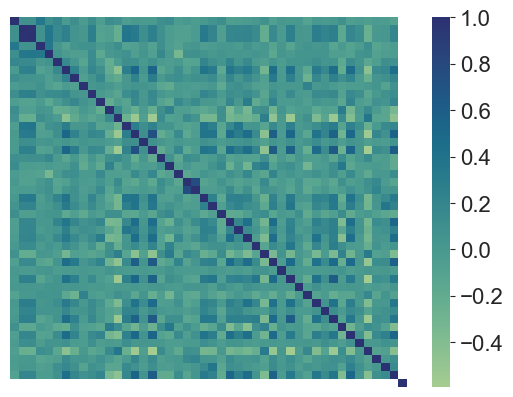

In [22]:
# corr_m = pd.DataFrame(X_norm[mutual_info_features]).corr(method="kendall").T
corr_m = pd.DataFrame(X_norm).corr(method="kendall").T

corr_map = matplotlib.colormaps['crest']
ax = sns.heatmap(corr_m, annot=False, cmap=corr_map, xticklabels=False, yticklabels=False)
ax.tick_params(left=False, bottom=False)
plt.show()

In [23]:
# no value is directly correlated
corr_m.where(corr_m==-1).stack()

Series([], dtype: float64)

In [24]:
np.fill_diagonal(corr_m.values, 0)
corr_m.where(corr_m==1).stack()

Series([], dtype: float64)

In [25]:
from collections import Counter
Counter(y_test)

Counter({'5': 90, '6': 90, '2': 90, '3': 90, '1': 90, '4': 90})

In [26]:
num2condition = {v: k for k, v in condition2num.items()}

In [27]:
# reg = LogisticRegression(solver='lbfgs', max_iter=100).fit(X_train[mutual_info_features], y_train)
reg = LogisticRegression(solver='lbfgs', max_iter=100).fit(X_train, y_train)

In [28]:
# preds = reg.predict(X_test[mutual_info_features])
preds = reg.predict(X_test)

In [29]:
# reg.score(X=X_test[mutual_info_features], y=y_test) # accuracy
reg.score(X=X_test, y=y_test) # accuracy

0.8111111111111111

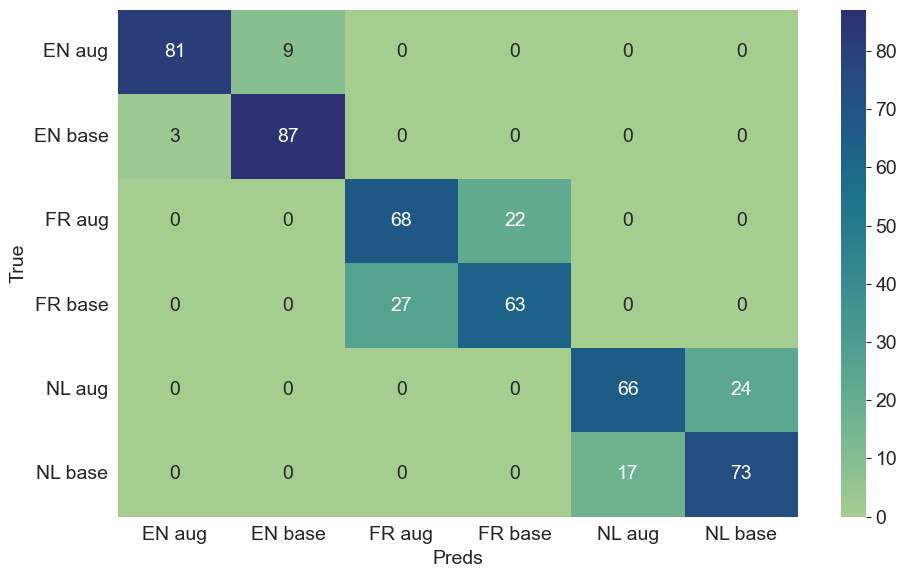

In [67]:
plt.figure(figsize=(10,6))
heatmap_data = confusion_matrix(y_true=[num2condition[x] for x in y_test], y_pred=[num2condition[x] for x in preds], labels=list(num2condition.values()))
heatmap_data = pd.DataFrame(heatmap_data, index=list(num2condition.values()), columns=list(num2condition.values()))
ax = sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap="crest")
ax.tick_params("y", labelrotation=0)
ax.set_xlabel('Preds')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig("../figs/"+setting + "_logistic_regression_heatmap.svg")
plt.show()

In [31]:
coefficients = reg.coef_[0]
odds_ratios = np.exp(coefficients)


# Display feature importance using coefficients and odds ratios
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
})
print("\nFeature Importance (Coefficient and Odds Ratio):")
print(feature_importance.sort_values(by='Coefficient', ascending=False))


Feature Importance (Coefficient and Odds Ratio):
                 Feature  Coefficient  Odds Ratio
25         upos_dist_VBG     1.097290    2.996037
44          upos_dist_IN     0.984304    2.675948
16        upos_dist_PRP$     0.848214    2.335471
23          upos_dist_VB     0.842010    2.321027
26         upos_dist_WRB     0.582325    1.790196
37          upos_dist_CC     0.568079    1.764873
6           upos_dist_RB     0.507525    1.661175
40         upos_dist_JJR     0.487598    1.628399
32          upos_dist_DT     0.474366    1.606995
39         upos_dist_VBN     0.461150    1.585897
13        upos_dist_NNPS     0.412779    1.511012
21          upos_dist_``     0.404649    1.498776
7          upos_dist_WP$     0.396541    1.486674
36          upos_dist_EX     0.369419    1.446893
30         upos_dist_PRP     0.368078    1.444955
28           upos_dist_,     0.362960    1.437578
10          upos_dist_WP     0.326309    1.385844
29         upos_dist_VBP     0.320140    1.377321


In [32]:
from sklearn.inspection import permutation_importance
model_fi = permutation_importance(reg, X_test, y_test)

## Testing on random data

In [45]:
test_bl = pd.read_csv("ProfilingUD_Code_doc_BL.out", sep="\t", encoding="utf-8")

In [46]:
test_bl['y'] = [x.split('.')[0].split('_')[-1] + ' base' for x in test_bl['identifier']]

In [47]:
y_BL = [condition2num[i] for i in test_bl.y]
test_bl = test_bl.drop(columns=["y", 'identifier', 'n_sentences', 'n_tokens'], axis=0)
test_bl = test_bl[X.columns]
scaler = StandardScaler()
X_norm_BL = pd.DataFrame(scaler.fit_transform(test_bl), columns=X.columns)

In [48]:
len(set(X.columns) - set(test_bl.columns))

0

In [49]:
bl_preds = reg.predict(X_norm_BL)

In [68]:
reg.score(X=X_norm_BL, y=y_BL) # accuracy

0.44533333333333336

In [50]:
len(X_norm_BL), len(bl_preds)

(6000, 6000)

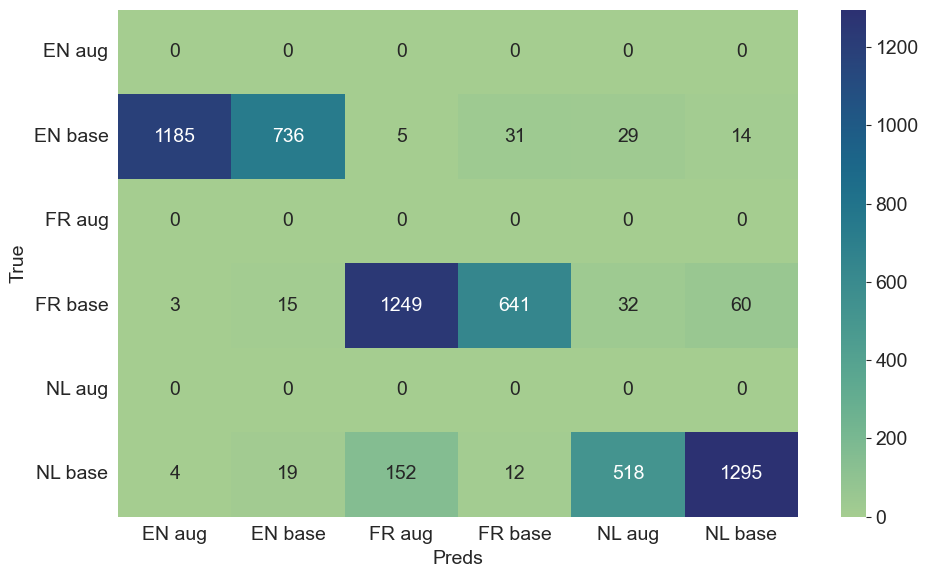

In [66]:
plt.figure(figsize=(10,6))
heatmap_data = confusion_matrix(y_true=[num2condition[y] for y in y_BL], y_pred=[num2condition[x] for x in bl_preds])
heatmap_data = pd.DataFrame(heatmap_data, index=list(num2condition.values()), columns=list(num2condition.values()))
ax = sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap="crest")
ax.tick_params("y", labelrotation=0)
ax.set_xlabel('Preds')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig("../figs/"+setting + "_logistic_regression_heatmap_bl.svg")
plt.show()

In [65]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

[]

<Figure size 1000x2000 with 0 Axes>

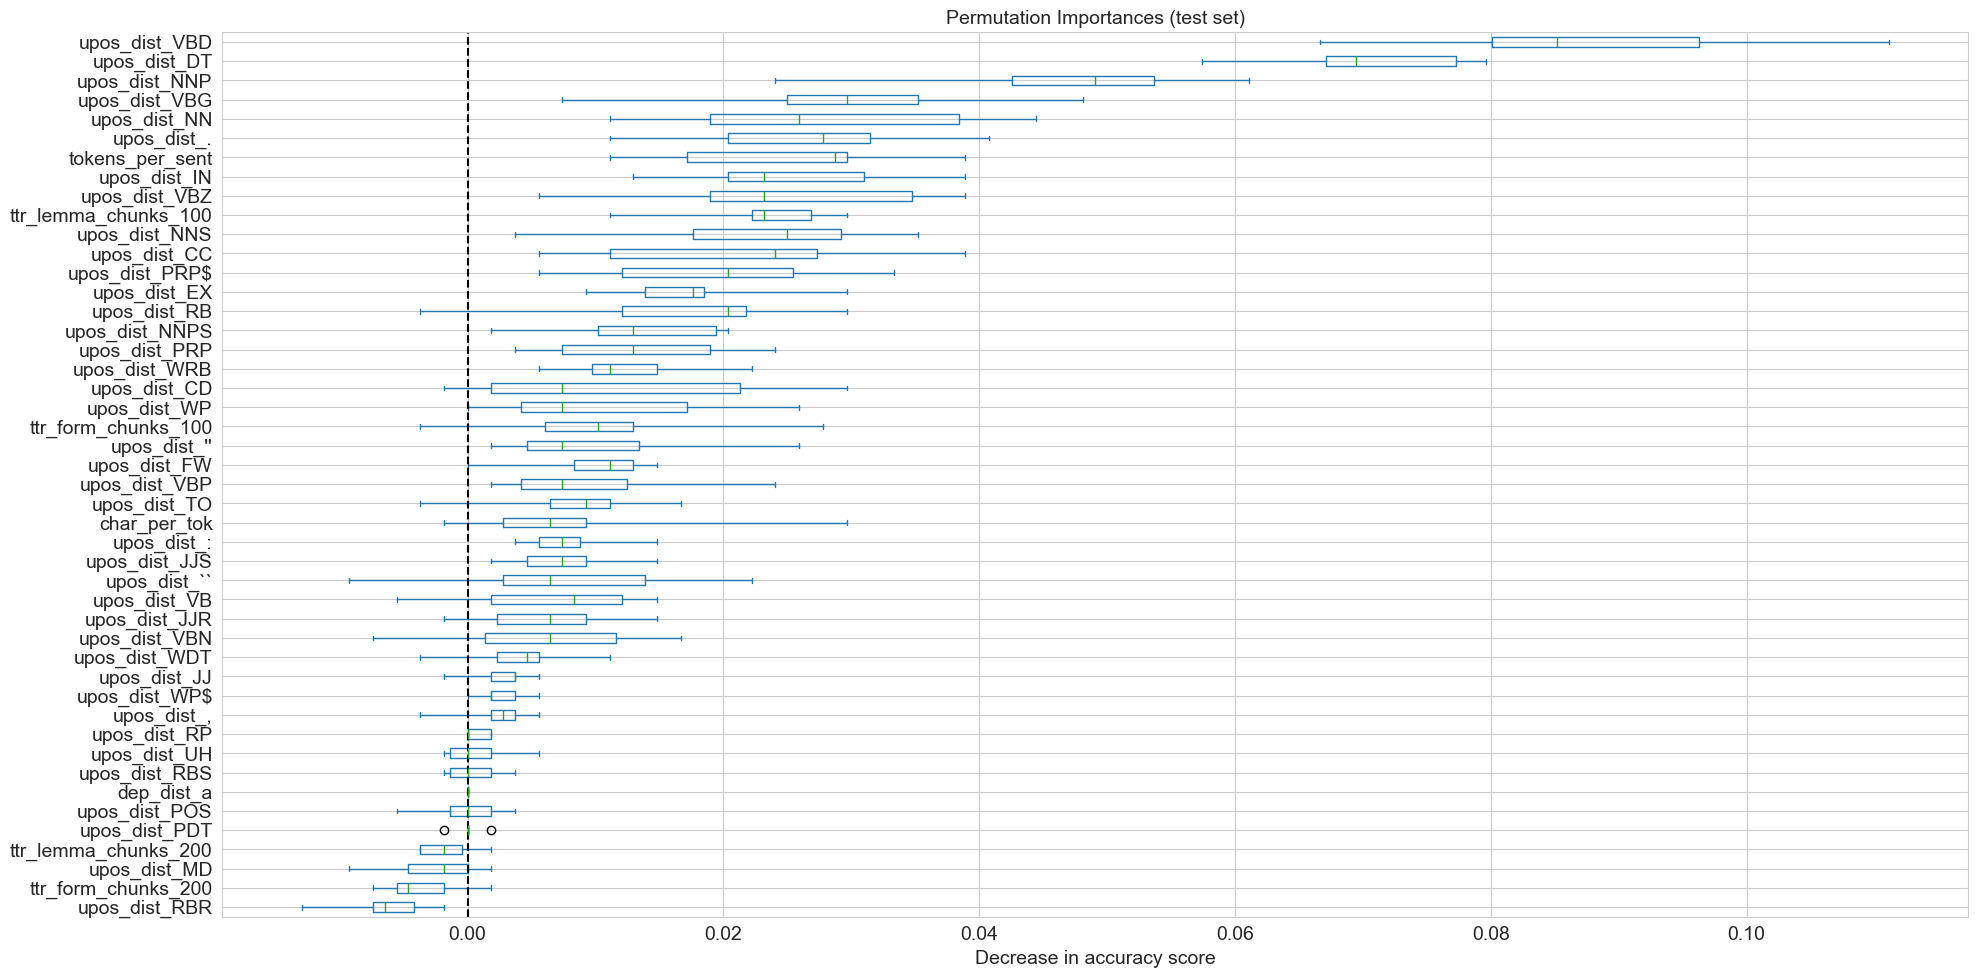

In [42]:
from sklearn.inspection import permutation_importance

plt.figure(figsize=(10,20))

result = permutation_importance(
    reg, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_importances_idx = result.importances_mean.argsort()

importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)

ax = importances.plot.box(vert=False, whis=10, figsize=(20, 10))
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
plt.plot()

In [43]:
# Stratified K-fold validation repeated 3 times over 10 folds 
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from numpy import mean, std

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
# evaluate the model and collect the scores
acc = cross_val_score(reg, X_norm, y, scoring='accuracy', cv=cv, n_jobs=-1)
precision = cross_val_score(reg, X_norm, y, cv=cv, n_jobs=-1, scoring='precision_macro')
recall = cross_val_score(reg, X_norm, y, cv=cv, n_jobs=-1, scoring='f1_macro')
f1 = cross_val_score(reg, X_norm, y, cv=cv, n_jobs=-1, scoring='recall_macro')

# report the model performance
print('Mean Accuracy: %.3f (%.3f)' % (mean(acc), std(acc)))
print('Mean Precision: %.3f (%.3f)' % (mean(precision), std(precision)))
print('Mean Recall: %.3f (%.3f)' % (mean(recall), std(recall)))
print('Mean F1: %.3f (%.3f)' % (mean(f1), std(f1)))

Mean Accuracy: 0.827 (0.024)
Mean Precision: 0.830 (0.024)
Mean Recall: 0.827 (0.024)
Mean F1: 0.827 (0.024)


In [44]:
cv.

SyntaxError: invalid syntax (4185309349.py, line 1)

## TSNE plot

Not using pca explicitly since it is only linear

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
num2condition.values()

In [ ]:
tsne = TSNE(n_components=2, learning_rate=5, init="pca", perplexity=30, max_iter=2000, metric='l1', random_state=42)
# changing multiple params for all features and for mutual_info features, distance: 
#       learning rate, random, perplexity and max_iter, plots look about the same 
#       (as in languages are clustered together and seems like there is not much difference 
#       between baseline and augmented here, maybe except for french?)

# x_tsne = tsne.fit_transform(X_norm[mutual_info_features])
x_tsne = pd.DataFrame(tsne.fit_transform(X_norm))
print(tsne.kl_divergence_)

In [ ]:
x_tsne["Plot"] = "tSNE"

In [ ]:
color_map = {label: cmap[i] for i, label in enumerate(num2condition.values())}
fig = px.scatter(x=x_tsne[0], y=x_tsne[1], color=[num2condition[i] for i in y], 
                 color_discrete_map=color_map, category_orders={'color': sorted(list(color_map.keys()))},
                  width=1000, height=450, opacity=0.7)
fig.update_traces(marker=dict(size=5))
fig.update_yaxes(title_text="")
fig.update_xaxes(title_text="")
fig.update_layout(legend_title_text="")
fig.update_layout(
    font=dict(
        family="Arial",  # or "Times New Roman"
        size=20,         # increase font size for better readability in LaTeX
        color="black"
    ),

)
fig.update_layout(
    legend=go.layout.Legend(
        itemsizing='constant'
        # Set the itemsizing attribute to 'constant'
    )
)
fig.update_layout(
    legend=dict(
        font=dict(
            size=20,
            color="black"
        ),
    ))
fig.show()
fig.write_image("../figs/"+setting+"_tsne.png", width=1000, height=450, scale=1)

## UMAP plot

In [ ]:
import umap as up

In [ ]:
fit = up.UMAP(n_neighbors=10, min_dist=0.5, n_components=2, metric='l1', random_state=42)
# similar result to t-sne (seems like for french there is a slight difference in some augmented answers
u = pd.DataFrame(fit.fit_transform(X_norm))

In [ ]:
u["Plot"] = "UMAP"

In [ ]:
color_map = {label: cmap[i] for i, label in enumerate(num2condition.values())}

sns.set(style='white', rc={'figure.figsize':(10,6)})
fig = px.scatter(x=u[0], y=u[1], color=[num2condition[i] for i in y], 
                 color_discrete_map=color_map, category_orders={'color': sorted(list(color_map.keys()))},
                  width=1000, height=450, opacity=0.7)
fig.update_traces(marker=dict(size=5))
fig.update_yaxes(title_text="")
fig.update_xaxes(title_text="")
fig.update_layout(legend_title_text="")
fig.update_layout(
    font=dict(
        family="Arial",  # or "Times New Roman"
        size=20,         # increase font size for better readability in LaTeX
        color="black"
    ),

)
fig.update_layout(
    legend=go.layout.Legend(
        itemsizing='constant'
        # Set the itemsizing attribute to 'constant'
    )
)
fig.update_layout(
    legend=dict(
        font=dict(
            size=20,
            color="black"
        ),
    ))
fig.show()
fig.write_image("../figs/"+setting+"_umap.png", width=1000, height=450, scale=1)

In [ ]:
all_plots = pd.concat([u,x_tsne])